# Z3 wall-width $\to$ lattice-parameter calculator (PRS runs)

Adjacent $Z_3$ wall profile from the two-field BVP (gradient-flow relaxation +
continuation in $\beta_N$), mirroring `wall_width_box_calculator_Z4.ipynb`.

**Conventions** (identical to the paper's Fig. 2): $z=\mu x$, fields in units
$\mu/\sqrt{\lambda_1}$, so $\sigma_{Z_3}=\mu^3\bar\sigma/\lambda_1$ and
$\delta=\bar\delta/\mu$. $\bar\delta$ = 18%$\to$82% cumulative-energy width
(same definition as the Z4 notebook).

**Coordinate dictionary** (all sympy-verified): bounded coordinate
$\beta_N=(1-R^2)/(1+R^2)\in(0,1)$ with $R=\rho_{\rm saddle}/\rho_{\rm vev}$;
$R=\sqrt{(1-\beta_N)/(1+\beta_N)}$; couplings at $\mu=1$, $h$-vev $=1$:
$\lambda_1=1/R$, $\lambda_2=\sqrt2(1-R)/(3R)$; $\kappa=m_a^2/m_h^2=3(1-R)/(1+R)<3$;
old unbounded coordinate $\beta_3^{\rm old}=3\lambda_2/\sqrt{8\lambda_1}=(1-R)/(2\sqrt R)$.

Reduced EOM (single parameter $\gamma=3\lambda_2/\sqrt{2\lambda_1}=(1-R)/\sqrt R$,
vacuum $\bar u = 1/\sqrt R$):
$u''=-u+u(u^2+w^2)+\gamma(w^2-u^2)$, $w''=-w+w(u^2+w^2)+2\gamma uw$,
BCs $(u,w)$: $(\bar u,0)\to\bar u(-\tfrac12,\tfrac{\sqrt3}2)$.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid, simpson

CACHE = 'z3_wall_curve_cache.npy'   # rows: beta_N, sigma_bar, delta_bar, min|phi|/vev

def R_of_beta(b):  return np.sqrt((1.0 - b)/(1.0 + b))
def beta3_old(b):  R = R_of_beta(b); return (1.0 - R)/(2.0*np.sqrt(R))
def kappa_of(b):   R = R_of_beta(b); return 3.0*(1.0 - R)/(1.0 + R)
def lam1_of(b):    return 1.0/R_of_beta(b)
def lam2_of(b):    R = R_of_beta(b); return np.sqrt(2.0)*(1.0 - R)/(3.0*R)

def relax(beta, guess=None, dz=0.04, max_iters=600000):
    # gradient-flow relaxation of the planar-wall BVP; returns converged profile
    R = R_of_beta(beta); g = (1.0 - R)/np.sqrt(R); ub = 1.0/np.sqrt(R)
    ma = np.sqrt(3.0*(1.0 - R)/R)            # dimensionless angular mass
    Z = max(30.0, 18.0/ma)
    z = np.arange(-Z, Z + dz/2, dz)
    if guess is None:
        w0 = 2.0 + 1.516/ma
        th = (np.pi/3.0)*(1.0 + np.tanh(z/w0))
        r  = ub*(1.0 - (1.0 - R)/np.cosh(z/w0))
        u, w = r*np.cos(th), r*np.sin(th)
    else:
        zo, uo, wo = guess
        u = np.interp(z, zo, uo, left=uo[0], right=uo[-1])
        w = np.interp(z, zo, wo, left=wo[0], right=wo[-1])
    u[0], w[0], u[-1], w[-1] = ub, 0.0, -0.5*ub, np.sqrt(3)/2*ub
    dt = 0.4*dz*dz
    res = np.inf
    for it in range(max_iters):
        lapu = np.zeros_like(u); lapw = np.zeros_like(w)
        lapu[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2])/dz**2
        lapw[1:-1] = (w[2:] - 2*w[1:-1] + w[:-2])/dz**2
        r2 = u*u + w*w
        fu = lapu - (-u + u*r2 + g*(w*w - u*u))
        fw = lapw - (-w + w*r2 + 2.0*g*u*w)
        fu[0] = fu[-1] = fw[0] = fw[-1] = 0.0
        u += dt*fu; w += dt*fw
        if it % 20000 == 19999:
            res = max(np.abs(fu).max(), np.abs(fw).max())
            if res < 1e-11:
                break
    return z, u, w, g, ub, res

def measures(z, u, w, g, ub):
    up = np.gradient(u, z); wp = np.gradient(w, z)
    r2 = u*u + w*w
    V  = -0.5*r2 + 0.25*r2*r2 - (g/3.0)*u*(u*u - 3.0*w*w)
    V0 = -0.5*ub*ub + 0.25*ub**4 - (g/3.0)*ub**3
    eps = np.clip(0.5*(up*up + wp*wp) + (V - V0), 0, None)
    sigma = simpson(y=eps, x=z)
    cum = cumulative_trapezoid(eps, z, initial=0); tot = cum[-1]
    lo = np.interp(0.18*tot, cum, z); hi = np.interp(0.82*tot, cum, z)
    return sigma, hi - lo, np.sqrt(r2.min())/ub

def build_curve(bmin=0.02, bmax=0.95, step=0.01, anchor=0.5):
    rows = {}
    for direction in (np.arange(anchor, bmax + 1e-9, step),
                      np.arange(anchor - step, bmin - 1e-9, -step)):
        guess = None
        for b in direction:
            b = round(float(b), 4)
            z, u, w, g, ub, res = relax(b, guess=guess)
            if res > 1e-8:
                print(f'beta={b}: residual {res:.1e} not converged, skipping'); continue
            guess = (z, u, w)
            rows[b] = measures(z, u, w, g, ub)
    bs = np.array(sorted(rows))
    return np.vstack([bs,
                      np.array([rows[b][0] for b in bs]),
                      np.array([rows[b][1] for b in bs]),
                      np.array([rows[b][2] for b in bs])])

if os.path.exists(CACHE):
    curve = np.load(CACHE)
    print(f'loaded cached curve: {curve.shape[1]} beta points '
          f'({curve[0,0]:.2f}..{curve[0,-1]:.2f})')
else:
    curve = build_curve()          # ~10 min
    np.save(CACHE, curve)
_B, _S, _D, _RM = curve

def sigma_adj(b): return float(np.interp(b, _B, _S))
def delta_adj(b): return float(np.interp(b, _B, _D))
def rmin_adj(b):  return float(np.interp(b, _B, _RM))

# sanity anchors: paper Fig.2 (sigma~8, delta~0.75 at beta3_old=1) + sine-Gordon limit
b_anchor = 0.943   # beta3_old = 1.00
print(f'beta3_old=1 anchor: sigma_bar = {sigma_adj(b_anchor):.2f} (Fig.2 ~10), '
      f'delta_bar = {delta_adj(b_anchor):.3f} (Fig.2 ~1)')
R = R_of_beta(0.05); ma = np.sqrt(3*(1-R)/R)
print(f'string limit beta_N=0.05: delta_bar = {delta_adj(0.05):.3f} vs sine-Gordon '
      f'1.516/m_a = {1.516/ma:.3f}  ({100*abs(delta_adj(0.05)*ma/1.516-1):.1f}% off)')

loaded cached curve: 91 beta points (0.05..0.95)
beta3_old=1 anchor: sigma_bar = 8.07 (Fig.2 ~10), delta_bar = 0.754 (Fig.2 ~1)
string limit beta_N=0.05: delta_bar = 3.810 vs sine-Gordon 1.516/m_a = 3.864  (1.4% off)


In [2]:
# ---- lattice sizing table (all lengths in program units, mu=1) ----------------
LATTICES = [
    ('validation  N=512  L=100  ', 512, 100.0),
    ('production  N=1024 L=358.4', 1024, 358.4),   # = Z4 long-scan card
    ('hires       N=1024 L=279  ', 1024, 279.0),   # = Z4 b40p9_hires card
]
GRID = [0.1, 0.3, 0.5, 0.7, 0.9]

print(f'{"beta_N":>6s} {"R":>7s} {"kappa":>7s} {"lambda1":>9s} {"lambda2":>9s}'
      f' {"sigma":>7s} {"delta":>6s} {"min|phi|":>8s}')
for b in GRID:
    print(f'{b:6.1f} {R_of_beta(b):7.4f} {kappa_of(b):7.4f} {lam1_of(b):9.6f}'
          f' {lam2_of(b):9.6f} {sigma_adj(b):7.3f} {delta_adj(b):6.3f} {rmin_adj(b):8.3f}')

print()
hdr = f'{"cells/wall":>26s}: ' + ''.join(f'b={b:<6.1f}' for b in GRID)
print(hdr)
for name, N, L in LATTICES:
    cells = [delta_adj(b)*N/L for b in GRID]
    print(f'{name:>26s}: ' + ''.join(f'{c:<8.2f}' for c in cells))
print()
for eta in [50, 150]:
    print(f'horizons/side at eta={eta}: ' +
          ', '.join(f'{name.split()[0]}={L/(1+eta):.2f}' for name, N, L in LATTICES))
print('\nrule of thumb: need >= 3-4 cells/wall; box >= 2-3 horizons/side at end of run')

beta_N       R   kappa   lambda1   lambda2   sigma  delta min|phi|
   0.1  0.9045  0.1504  1.105542  0.049753   0.487  2.657    0.859
   0.3  0.7338  0.4606  1.362770  0.171012   0.908  1.550    0.672
   0.5  0.5774  0.8038  1.732051  0.345092   1.388  1.243    0.549
   0.7  0.4201  1.2251  2.380476  0.650763   2.237  1.059    0.456
   0.9  0.2294  1.8804  4.358899  1.583400   5.299  0.843    0.368

                cells/wall: b=0.1   b=0.3   b=0.5   b=0.7   b=0.9   
validation  N=512  L=100  : 13.61   7.94    6.36    5.42    4.32    
production  N=1024 L=358.4: 7.59    4.43    3.55    3.03    2.41    
hires       N=1024 L=279  : 9.75    5.69    4.56    3.89    3.09    

horizons/side at eta=50: validation=1.96, production=7.03, hires=5.47
horizons/side at eta=150: validation=0.66, production=2.37, hires=1.85

rule of thumb: need >= 3-4 cells/wall; box >= 2-3 horizons/side at end of run


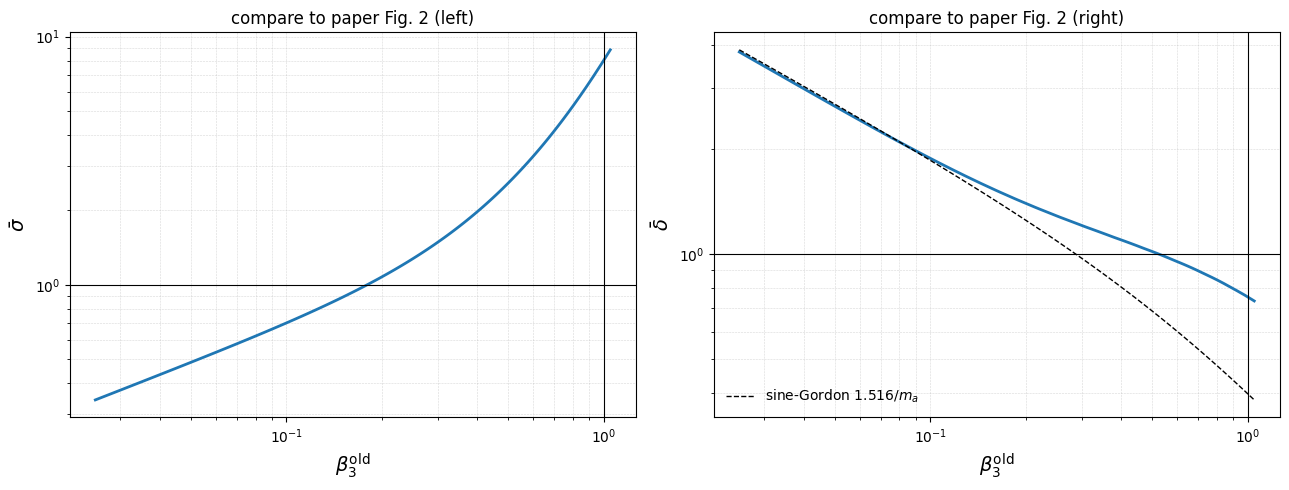

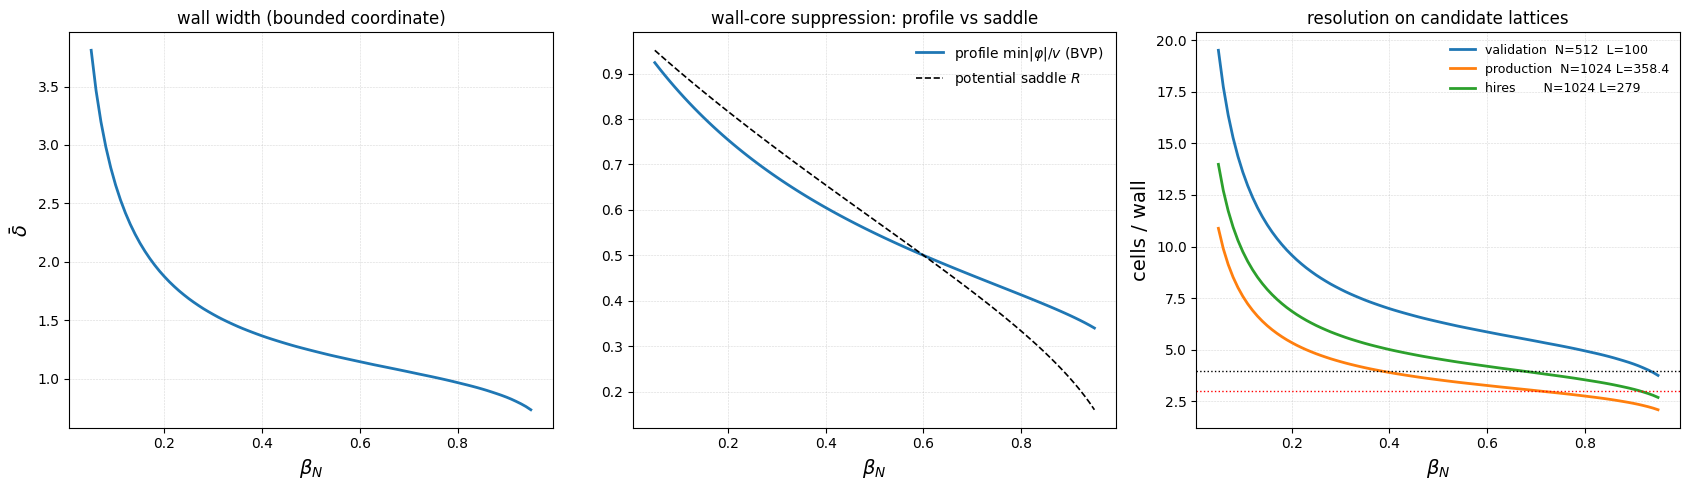

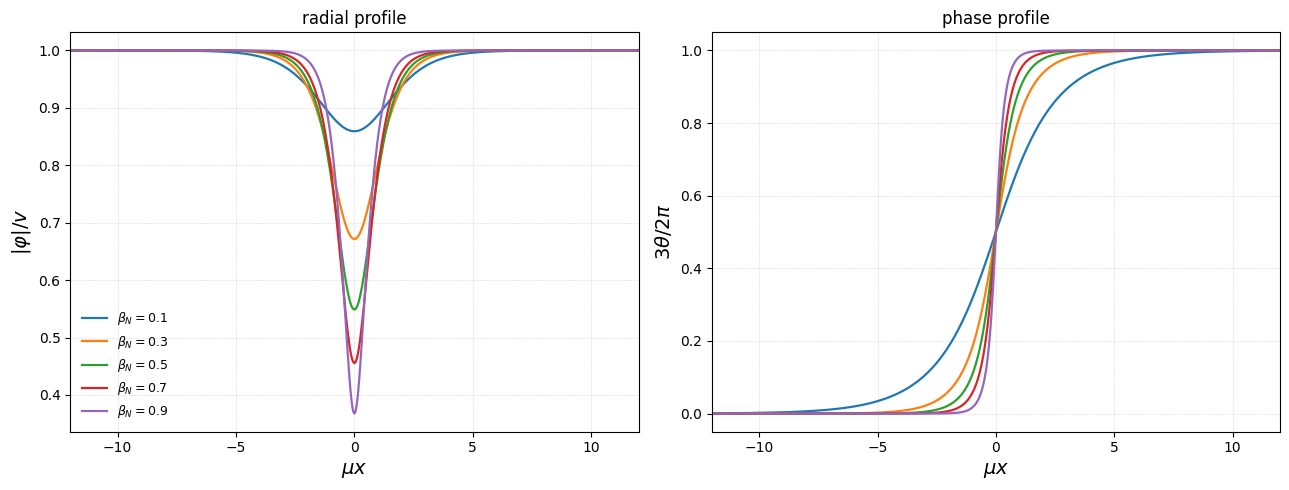

In [3]:
# ---- verification plots --------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
b3 = beta3_old(_B)
axes[0].loglog(b3, _S, lw=2)
axes[0].axhline(1, color='k', lw=0.8); axes[0].axvline(1, color='k', lw=0.8)
axes[0].set_xlabel(r'$\beta_3^{\rm old}$', fontsize=14)
axes[0].set_ylabel(r'$\bar\sigma$', fontsize=14)
axes[0].set_title('compare to paper Fig. 2 (left)')
axes[1].loglog(b3, _D, lw=2)
R_ = R_of_beta(_B); ma_ = np.sqrt(3*(1-R_)/R_)
axes[1].loglog(b3, 1.516/ma_, 'k--', lw=1, label='sine-Gordon $1.516/m_a$')
axes[1].axhline(1, color='k', lw=0.8); axes[1].axvline(1, color='k', lw=0.8)
axes[1].set_xlabel(r'$\beta_3^{\rm old}$', fontsize=14)
axes[1].set_ylabel(r'$\bar\delta$', fontsize=14)
axes[1].set_title('compare to paper Fig. 2 (right)')
axes[1].legend(frameon=False)
for ax in axes: ax.grid(True, which='both', ls='--', lw=0.4, alpha=0.5)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].plot(_B, _D, lw=2)
axes[0].set_xlabel(r'$\beta_N$', fontsize=14); axes[0].set_ylabel(r'$\bar\delta$', fontsize=14)
axes[0].set_title('wall width (bounded coordinate)')
axes[1].plot(_B, _RM, lw=2, label=r'profile $\min|\varphi|/v$ (BVP)')
axes[1].plot(_B, R_of_beta(_B), 'k--', lw=1.2, label=r'potential saddle $R$')
axes[1].set_xlabel(r'$\beta_N$', fontsize=14)
axes[1].set_title('wall-core suppression: profile vs saddle')
axes[1].legend(frameon=False)
for name, N, L in LATTICES:
    axes[2].plot(_B, np.interp(_B, _B, _D)*N/L, lw=2, label=name.strip())
axes[2].axhline(4, color='k', ls=':', lw=1); axes[2].axhline(3, color='r', ls=':', lw=1)
axes[2].set_xlabel(r'$\beta_N$', fontsize=14); axes[2].set_ylabel('cells / wall', fontsize=14)
axes[2].set_title('resolution on candidate lattices')
axes[2].legend(frameon=False, fontsize=9)
for ax in axes: ax.grid(True, ls='--', lw=0.4, alpha=0.5)
plt.tight_layout(); plt.show()

# wall profiles at the scan grid
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for b in GRID:
    z, u, w, g, ub, res = relax(b)
    r = np.sqrt(u*u + w*w)/ub
    th = np.unwrap(np.arctan2(w, u))
    axes[0].plot(z, r, lw=1.6, label=rf'$\beta_N={b}$')
    axes[1].plot(z, th*3/(2*np.pi), lw=1.6)
axes[0].set_xlim(-12, 12); axes[1].set_xlim(-12, 12)
axes[0].set_xlabel(r'$\mu x$', fontsize=14); axes[0].set_ylabel(r'$|\varphi|/v$', fontsize=14)
axes[1].set_xlabel(r'$\mu x$', fontsize=14); axes[1].set_ylabel(r'$3\theta/2\pi$', fontsize=14)
axes[0].legend(frameon=False, fontsize=9)
axes[0].set_title('radial profile'); axes[1].set_title('phase profile')
for ax in axes: ax.grid(True, ls='--', lw=0.4, alpha=0.5)
plt.tight_layout(); plt.show()

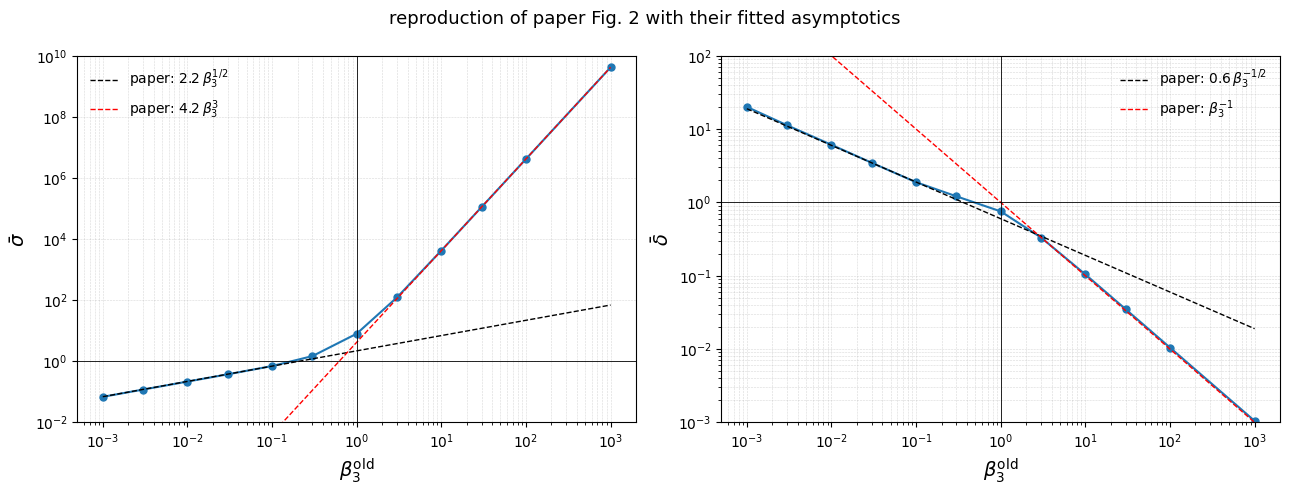

measured: sigma = 2.161 b^0.499 (small), 4.186 b^3.000 (large); delta = 1.047 b^-1.000 (large)
paper fits: sigma = 2.2 b^0.5 (small), 4.2 b^3 (large); delta = 0.6 b^-0.5, 1.0 b^-1


In [4]:
# ---- wide-range check vs paper Fig. 2 (full beta3_old range, both asymptotics) ----
# cached in z3_wall_widecheck_cache.npy (cols: beta3_old, sigma_bar, delta_bar); ~12 min to redo
WIDE_CACHE = 'z3_wall_widecheck_cache.npy'

def solve_b3(b3, iters=400000):
    # cold relaxation directly at beta3_old = b3 with adaptive dz/Z (vev ~ 2*b3 at large b3)
    g  = 2.0*b3
    ub = 0.5*(g + np.sqrt(g*g + 4.0))
    ma = np.sqrt(3.0*g*ub)
    mh = np.sqrt(-1.0 + 3.0*ub*ub - 2.0*g*ub)
    mmax, mmin = max(ma, mh), min(ma, mh)
    dz = min(0.04, 0.15/mmax)
    Z  = max(30.0/mmin, 12.0/mmin + 5.0)
    z  = np.arange(-Z, Z + dz/2, dz)
    rs = 0.5*(-g + np.sqrt(g*g + 4.0))
    w0 = 2.0/mmin
    with np.errstate(over='ignore'):
        th = (np.pi/3.0)*(1.0 + np.tanh(z/w0))
        r  = ub - (ub - rs)/np.cosh(z/w0)
    u, w = r*np.cos(th), r*np.sin(th)
    u[0], w[0], u[-1], w[-1] = ub, 0.0, -0.5*ub, np.sqrt(3)/2*ub
    dt = 0.4*dz*dz
    for it in range(iters):
        lapu = np.zeros_like(u); lapw = np.zeros_like(w)
        lapu[1:-1] = (u[2:]-2*u[1:-1]+u[:-2])/dz**2
        lapw[1:-1] = (w[2:]-2*w[1:-1]+w[:-2])/dz**2
        r2 = u*u + w*w
        fu = lapu - (-u + u*r2 + g*(w*w - u*u))
        fw = lapw - (-w + w*r2 + 2.0*g*u*w)
        fu[0]=fu[-1]=fw[0]=fw[-1]=0.0
        u += dt*fu; w += dt*fw
        if it % 20000 == 19999:
            if max(np.abs(fu).max(), np.abs(fw).max()) < 1e-10*max(1.0, ub**3):
                break
    up = np.gradient(u, z); wp = np.gradient(w, z)
    r2 = u*u + w*w
    V  = -0.5*r2 + 0.25*r2*r2 - (g/3.0)*u*(u*u - 3.0*w*w)
    V0 = -0.5*ub*ub + 0.25*ub**4 - (g/3.0)*ub**3
    eps = np.clip(0.5*(up*up + wp*wp) + (V - V0), 0, None)
    sigma = simpson(y=eps, x=z)
    cum = cumulative_trapezoid(eps, z, initial=0); tot = cum[-1]
    return sigma, np.interp(0.82*tot, cum, z) - np.interp(0.18*tot, cum, z)

if os.path.exists(WIDE_CACHE):
    wide = np.load(WIDE_CACHE)
else:
    pts = [0.001,0.003,0.01,0.03,0.1,0.3,1.0,3.0,10.0,30.0,100.0,1000.0]
    wide = np.array([[b]+list(solve_b3(b)) for b in pts])
    np.save(WIDE_CACHE, wide)
b3w, sgw, dlw = wide.T

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bb = np.logspace(-3, 3, 200)
axes[0].loglog(b3w, sgw, 'o-', lw=1.5, ms=5)
axes[0].loglog(bb, 2.2*np.sqrt(bb), 'k--', lw=1, label=r'paper: $2.2\,\beta_3^{1/2}$')
axes[0].loglog(bb, 4.2*bb**3, 'r--', lw=1, label=r'paper: $4.2\,\beta_3^{3}$')
axes[0].set_ylim(1e-2, 1e10); axes[0].set_ylabel(r'$\bar\sigma$', fontsize=14)
axes[1].loglog(b3w, dlw, 'o-', lw=1.5, ms=5)
axes[1].loglog(bb, 0.6/np.sqrt(bb), 'k--', lw=1, label=r'paper: $0.6\,\beta_3^{-1/2}$')
axes[1].loglog(bb, 1.0/bb, 'r--', lw=1, label=r'paper: $\beta_3^{-1}$')
axes[1].set_ylim(1e-3, 1e2); axes[1].set_ylabel(r'$\bar\delta$', fontsize=14)
for ax in axes:
    ax.axhline(1, color='k', lw=0.6); ax.axvline(1, color='k', lw=0.6)
    ax.set_xlabel(r'$\beta_3^{\rm old}$', fontsize=14)
    ax.grid(True, which='both', ls='--', lw=0.4, alpha=0.5)
    ax.legend(frameon=False)
fig.suptitle('reproduction of paper Fig. 2 with their fitted asymptotics', fontsize=13)
plt.tight_layout(); plt.show()

for lab, pe, ce in [('sigma small', 0.5, 2.2), ('sigma large', 3.0, 4.2)]:
    pass
print('measured: sigma = %.3f b^%.3f (small), %.3f b^%.3f (large); delta = %.3f b^%.3f (large)' % (
    np.exp(np.polyfit(np.log(b3w[:3]), np.log(sgw[:3]), 1)[1]),
    np.polyfit(np.log(b3w[:3]), np.log(sgw[:3]), 1)[0],
    np.exp(np.polyfit(np.log(b3w[-3:]), np.log(sgw[-3:]), 1)[1]),
    np.polyfit(np.log(b3w[-3:]), np.log(sgw[-3:]), 1)[0],
    np.exp(np.polyfit(np.log(b3w[-3:]), np.log(dlw[-3:]), 1)[1]),
    np.polyfit(np.log(b3w[-3:]), np.log(dlw[-3:]), 1)[0]))
print('paper fits: sigma = 2.2 b^0.5 (small), 4.2 b^3 (large); delta = 0.6 b^-0.5, 1.0 b^-1')

### Caveats & how to use

- The profile-level core suppression $\min|\varphi|/v$ is **larger** than the potential
  saddle $R$ (the path trades depth for length); $R$ remains the exact *coordinate*,
  the BVP value is what the lattice should reproduce in wall interiors.
- $\bar\delta$ matches the sine-Gordon limit as $\beta_N\to0$ and the paper's Fig. 2
  at $\beta_3^{\rm old}=1$; the cached curve spans $\beta_N\in[0.05,0.95]$
  (delete `z3_wall_curve_cache.npy` to recompute, ~10 min).
- Under PRS the **comoving** width is frozen at $\bar\delta/\mu$: cells/wall
  $=\bar\delta\,N/(\mu L)$ for the whole run; horizons/side $=\mu L/(1+\eta)$.
- $Z_3$ has a single wall type (no non-adjacent walls, no $\beta=1/3$ transition);
  junctions where three walls meet are string-like, with core suppression deepening
  as $\beta_N\to1$ ($\kappa\to3$, $\mu^2\to0$).